In [1]:
import os
import cv2
import csv
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

# ----------------------------
# Configuration
# ----------------------------
IMG_SIZE = 256
N_IMAGES = 1000

SAVE_DIR = "Ideal_Test_Set"

os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(42)

In [2]:
# ==========================================================
# Ideal Interferogram Generator
# ==========================================================

def generate_ideal_interferogram(size=256):
    """
    Generates an ideal sinusoidal interferogram.

    Returns
    -------
    image : uint8 image
    angle : ground truth angle (degrees)
    """

    # -----------------------------
    # Random orientation
    # -----------------------------
    angle = np.random.uniform(-45, 135)
    theta = np.deg2rad(angle)

    # -----------------------------
    # Random fringe frequency
    # cycles across image
    # -----------------------------
    n_fringes = np.random.uniform(6, 18)

    # cycles/pixel
    frequency = n_fringes / size

    # -----------------------------
    # Random phase
    # -----------------------------
    phase = np.random.uniform(0, 2*np.pi)

    # -----------------------------
    # Coordinate grid
    # -----------------------------
    x = np.linspace(-size/2, size/2, size)
    y = np.linspace(-size/2, size/2, size)

    X, Y = np.meshgrid(x, y)

    # Coordinate along fringe normal
    u = X*np.cos(theta) + Y*np.sin(theta)

    # -----------------------------
    # Ideal sinusoidal intensity
    # -----------------------------
    image = 0.5 + 0.5*np.cos(2*np.pi*frequency*u + phase)

    # Convert to uint8
    image = (255 * image).astype(np.uint8)

    return image, angle, n_fringes

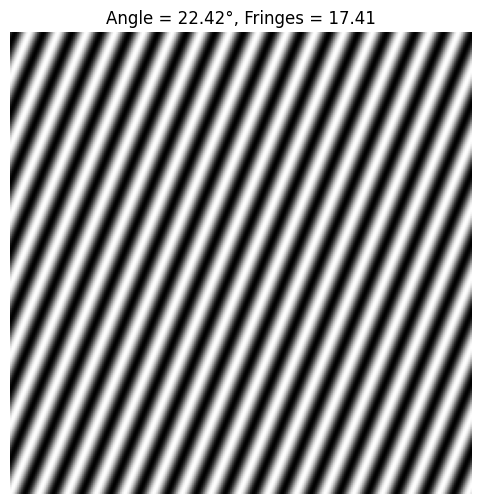

In [3]:
img, angle, n_fringes = generate_ideal_interferogram(256)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title(f"Angle = {angle:.2f}°, Fringes = {n_fringes:.2f}")
plt.axis("off")
plt.show()

In [19]:
# ==========================================================
# Generate Ideal Test Dataset
# ==========================================================

import os
import csv
from tqdm import tqdm

images_dir = os.path.join(SAVE_DIR, "images")
os.makedirs(images_dir, exist_ok=True)

csv_path = os.path.join(SAVE_DIR, "angles.csv")

with open(csv_path, "w", newline="") as f:

    writer = csv.writer(f)
    writer.writerow(["image", "angle", "n_fringes"])

    for i in tqdm(range(N_IMAGES), desc="Generating Images"):

        img, angle, n_fringes = generate_ideal_interferogram(IMG_SIZE)

        filename = f"{i:05d}.png"

        cv2.imwrite(
            os.path.join(images_dir, filename),
            img
        )

        writer.writerow([
            os.path.join(images_dir, filename),
            angle, n_fringes
        ])

print("\nDone!")
print(f"Images saved to : {images_dir}")
print(f"CSV saved to    : {csv_path}")
print(f"Total images    : {N_IMAGES}")

Generating Images: 100%|██████████| 1000/1000 [00:01<00:00, 805.06it/s]


Done!
Images saved to : Ideal_Test_Set\images
CSV saved to    : Ideal_Test_Set\angles.csv
Total images    : 1000


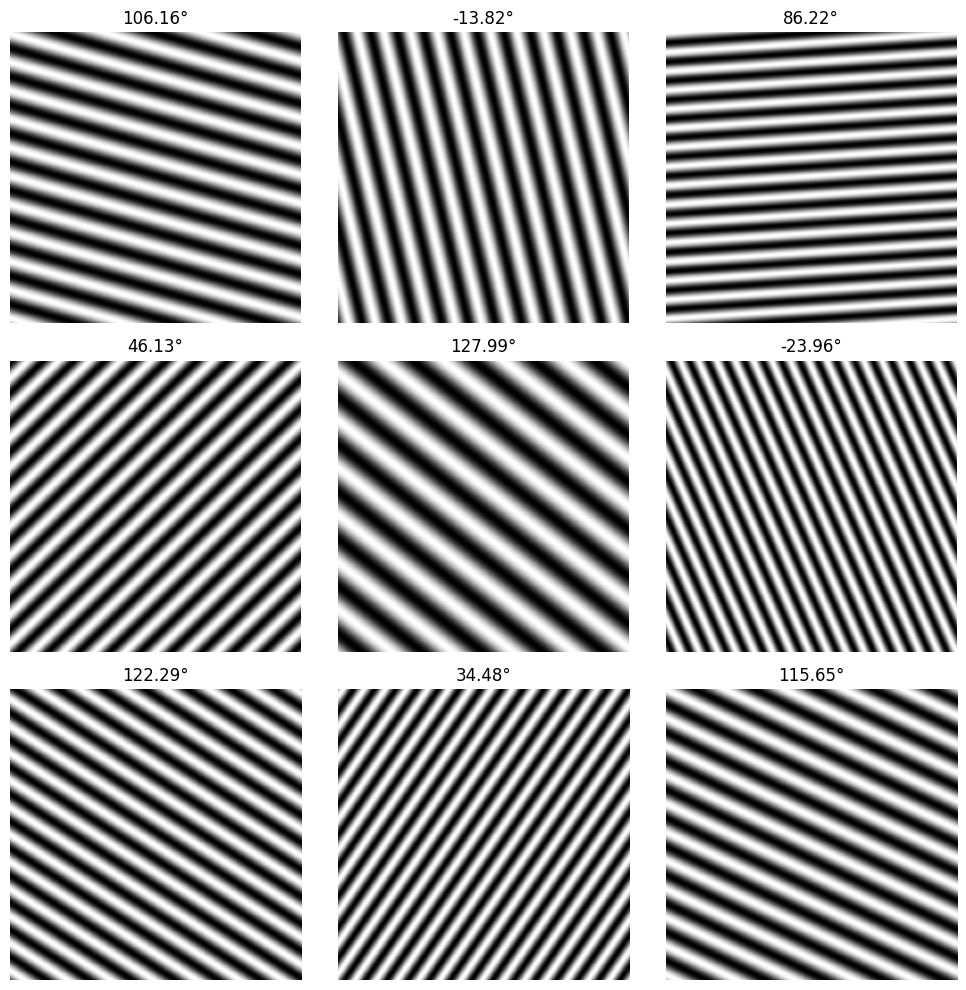

In [20]:
# ==========================================================
# Display Random Samples
# ==========================================================
images_dir = os.path.join(SAVE_DIR, "images")
csv_path = os.path.join(SAVE_DIR, "angles.csv")
import random

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax in axes.ravel():

    idx = random.randint(0, N_IMAGES - 1)

    img = cv2.imread(
        os.path.join(images_dir, f"{idx:05d}.png"),
        cv2.IMREAD_GRAYSCALE
    )

    angle = None

    with open(csv_path) as f:
        reader = csv.DictReader(f)
        rows = list(reader)
        angle = float(rows[idx]["angle"])

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{angle:.2f}°")
    ax.axis("off")

plt.tight_layout()
plt.show()

# model

In [22]:
import os
import glob
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device : {device}")

if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

Using device : cuda
NVIDIA GeForce RTX 3050


In [23]:
class FringeStem(nn.Module):
    """
    Initial feature extraction while preserving full spatial resolution.
    """

    def __init__(self, in_channels=1, out_channels=32):

        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels)
        )

        self.activation = nn.SiLU(inplace=True)

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):

        x = self.conv1(x)

        residual = x

        x = self.conv2(x)
        x = self.conv3(x)

        x = x + residual

        x = self.activation(x)

        return x
    

class FringeResidualBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        groups=8
    ):

        super().__init__()

        # ----------------------------------------------------
        # Ensure GroupNorm groups divide channels
        # ----------------------------------------------------
        groups = min(groups, out_channels)

        while out_channels % groups != 0:
            groups -= 1

        # ----------------------------------------------------
        # Main Branch
        # ----------------------------------------------------
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.norm1 = nn.GroupNorm(groups, out_channels)

        self.act = nn.SiLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.norm2 = nn.GroupNorm(groups, out_channels)

        # ----------------------------------------------------
        # Shortcut
        # ----------------------------------------------------
        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.GroupNorm(groups, out_channels)

            )

        else:

            self.shortcut = nn.Identity()

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.norm1(out)
        out = self.act(out)

        out = self.conv2(out)
        out = self.norm2(out)

        out = out + identity

        out = self.act(out)

        return out


class MultiScaleFringeBlock(nn.Module):

    def __init__(self, channels, groups=8):

        super().__init__()

        branch_channels = channels // 4

        # Make sure GroupNorm is valid
        groups = min(groups, branch_channels)
        while branch_channels % groups != 0:
            groups -= 1

        # ----------------------------------------------------
        # Branch 1 : Local Features
        # ----------------------------------------------------
        self.branch1 = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=1,
                dilation=1,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Branch 2 : Medium Receptive Field
        # ----------------------------------------------------
        self.branch2 = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=2,
                dilation=2,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Branch 3 : Large Receptive Field
        # ----------------------------------------------------
        self.branch3 = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=3,
                dilation=3,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Branch 4 : Global Context
        # ----------------------------------------------------
        self.branch4 = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=4,
                dilation=4,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Feature Fusion
        # ----------------------------------------------------
        self.fuse = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(min(8, channels), channels),

            nn.SiLU(inplace=True)

        )

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)

        out = torch.cat(
            [b1, b2, b3, b4],
            dim=1
        )

        out = self.fuse(out)

        return out + x

class DirectionalBlock(nn.Module):

    def __init__(self, channels, groups=8):

        super().__init__()

        branch_channels = channels // 4

        # ----------------------------------------------------
        # Ensure valid GroupNorm groups
        # ----------------------------------------------------
        groups = min(groups, branch_channels)
        while branch_channels % groups != 0:
            groups -= 1

        # ----------------------------------------------------
        # Horizontal Branch
        # ----------------------------------------------------
        self.horizontal = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=(1, 9),
                padding=(0, 4),
                groups=channels,
                bias=False
            ),

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Vertical Branch
        # ----------------------------------------------------
        self.vertical = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=(9, 1),
                padding=(4, 0),
                groups=channels,
                bias=False
            ),

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Local Branch
        # ----------------------------------------------------
        self.local = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Context Branch
        # ----------------------------------------------------
        self.context = nn.Sequential(

            nn.Conv2d(
                channels,
                branch_channels,
                kernel_size=3,
                dilation=2,
                padding=2,
                bias=False
            ),

            nn.GroupNorm(groups, branch_channels),

            nn.SiLU(inplace=True)

        )

        # ----------------------------------------------------
        # Fusion
        # ----------------------------------------------------
        self.fuse = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(min(8, channels), channels),

            nn.SiLU(inplace=True)

        )

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        h = self.horizontal(x)
        v = self.vertical(x)
        l = self.local(x)
        c = self.context(x)

        out = torch.cat(
            [h, v, l, c],
            dim=1
        )

        out = self.fuse(out)

        return out + x


class FringeNet(nn.Module):

    def __init__(self, in_channels=1):

        super().__init__()

        # ----------------------------------------------------
        # Stem
        # ----------------------------------------------------
        self.stem = FringeStem(
            in_channels=in_channels,
            out_channels=32
        )

        # ----------------------------------------------------
        # Stage 1
        # ----------------------------------------------------
        self.stage1 = nn.Sequential(

            FringeResidualBlock(32, 32),

            MultiScaleFringeBlock(32)

        )

        # ----------------------------------------------------
        # Stage 2
        # ----------------------------------------------------
        self.stage2 = nn.Sequential(

            FringeResidualBlock(
                32,
                64,
                stride=2
            ),

            MultiScaleFringeBlock(64)

        )

        # ----------------------------------------------------
        # Stage 3
        # ----------------------------------------------------
        self.stage3 = nn.Sequential(

            FringeResidualBlock(
                64,
                128,
                stride=2
            ),

            DirectionalBlock(128)

        )

        # ----------------------------------------------------
        # Stage 4
        # ----------------------------------------------------
        self.stage4 = nn.Sequential(

            FringeResidualBlock(
                128,
                256,
                stride=2
            ),

            DirectionalBlock(256)

        )

        # ----------------------------------------------------
        # Dual Global Pooling
        # ----------------------------------------------------
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        self.maxpool = nn.AdaptiveMaxPool2d(1)

        # ----------------------------------------------------
        # Regression Head
        # ----------------------------------------------------
        self.head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(512, 256),

            nn.SiLU(inplace=True),

            nn.Dropout(cfg.DROPOUT),

            nn.Linear(256, 128),

            nn.SiLU(inplace=True),

            nn.Dropout(cfg.DROPOUT * 0.5),

            nn.Linear(128, cfg.OUTPUT_DIM)

        )

        self._initialize_weights()

    def _initialize_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Linear):

                nn.init.kaiming_normal_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):

        x = self.stem(x)

        x = self.stage1(x)

        x = self.stage2(x)

        x = self.stage3(x)

        x = self.stage4(x)

        avg = self.avgpool(x)

        mx = self.maxpool(x)

        x = torch.cat([avg, mx], dim=1)

        x = self.head(x)

        x = F.normalize(x, p=2, dim=1)

        return x



In [24]:
from dataclasses import dataclass


@dataclass
class CFG:

    # MODEL_PATH = r"C:\Users\admin\Desktop\sandeep\FringeNet_last.pth"
    MODEL_PATH = r"C:\Users\admin\Desktop\sandeep\FringeNet_best.pth"
    IMAGE_SIZE = 224

    INPUT_FOLDER = r"C:\Users\admin\Desktop\sandeep\data_2"

    OUTPUT_FOLDER = r"C:\Users\admin\Desktop\sandeep\data_2\aligned_vertical"

    # --------------------------------------------------------
    # IMAGE EXTENSIONS
    # --------------------------------------------------------
    EXTENSIONS = (
        "*.png",
        "*.jpg",
        "*.jpeg",
        "*.bmp",
        "*.tif",
        "*.tiff"
    )

    # --------------------------------------------------------
    # INFERENCE
    # --------------------------------------------------------
    USE_TTA = True
    DROPOUT = 0.20
    SAVE_AS_PNG = False
    OUTPUT_DIM = 2
    PNG_COMPRESSION = 3

    JPG_QUALITY = 100


cfg = CFG()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("FRINGENET ALIGNMENT")

print(f"Device        : {device}")
print(f"Model         : {cfg.MODEL_PATH}")
print(f"Input Folder  : {cfg.INPUT_FOLDER}")
print(f"Output Folder : {cfg.OUTPUT_FOLDER}")
print(f"TTA           : {cfg.USE_TTA}")


FRINGENET ALIGNMENT
Device        : cuda
Model         : C:\Users\admin\Desktop\sandeep\FringeNet_best.pth
Input Folder  : C:\Users\admin\Desktop\sandeep\data_2
Output Folder : C:\Users\admin\Desktop\sandeep\data_2\aligned_vertical
TTA           : True


In [25]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# -----------------------------
# Create model
# -----------------------------
model = FringeNet().to(device)

# -----------------------------
# Load checkpoint
# -----------------------------
checkpoint = torch.load(
    r"C:\Users\admin\Desktop\sandeep\checkpoints\epoch_050.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model"])

model.eval()

print("✅ FringeNet loaded successfully.")

Using device: cuda
✅ FringeNet loaded successfully.


In [26]:
def read_image(path):
    """
    Read grayscale image.
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(path)

    return img


def zscore_normalize(img):
    """
    Zero mean, unit variance normalization.
    """

    img = img.astype(np.float32)

    mean = img.mean()

    std = img.std()

    return (img - mean) / (std + 1e-8)


def resize_with_padding(img, size):
    """
    Resize while preserving aspect ratio.
    Used ONLY for CNN inference.
    """

    h, w = img.shape

    scale = size / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    img = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    canvas = np.zeros(
        (size, size),
        dtype=np.float32
    )

    y0 = (size - new_h) // 2

    x0 = (size - new_w) // 2

    canvas[
        y0:y0 + new_h,
        x0:x0 + new_w
    ] = img

    return canvas


def rotate_keep_size(image, angle):
    """
    Rotate ORIGINAL image while preserving dimensions.
    Black borders are used.
    """

    h, w = image.shape

    center = (w / 2, h / 2)

    M = cv2.getRotationMatrix2D(
        center,
        -angle,
        1.0
    )

    rotated = cv2.warpAffine(

        image,

        M,

        (w, h),

        flags=cv2.INTER_CUBIC,

        borderMode=cv2.BORDER_CONSTANT,

        borderValue=0

    )

    return rotated


def verticality_score(image):
    """
    FFT-based score.
    Higher = fringes are more vertical.
    """

    profile = np.sum(
        image.astype(np.float32),
        axis=0
    )

    profile -= profile.mean()

    fft = np.abs(
        np.fft.rfft(profile)
    )

    if len(fft) <= 1:
        return 0.0

    return fft[1:].max()


print("✓ Utility functions loaded.")

✓ Utility functions loaded.


In [27]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FringeNet().to(device)

checkpoint = torch.load(
    cfg.MODEL_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model"])

model.eval()
print("FringeNet Loaded Successfully")
if "best_mae" in checkpoint:
    print(f"Best MAE : {checkpoint['best_mae']:.3f}°")

if "epoch" in checkpoint:
    print(f"Epoch    : {checkpoint['epoch']+1}")



# ============================================================
# HELPER FUNCTIONS
# ============================================================

def vector_to_angle(vec):
    """
    vec = [sin(theta), cos(theta)]
    returns angle in degrees (-180,180]
    """
    return np.degrees(np.arctan2(vec[0], vec[1]))


def angle_to_vector(angle):
    """
    angle (degrees)
    returns [sin(theta), cos(theta)]
    """
    theta = np.deg2rad(angle)

    return np.array(
        [
            np.sin(theta),
            np.cos(theta)
        ],
        dtype=np.float32
    )


def wrap_angle(angle):
    """
    Wrap angle into [-180,180)
    """
    return (angle + 180) % 360 - 180


# ------------------------------------------------------------
# Quick sanity check
# ------------------------------------------------------------

x = torch.randn(2, 1, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE).to(device)

with torch.no_grad():

    y = model(x)

print("Output Shape :", y.shape)

print("Vector Norms :", torch.norm(y, dim=1))

FringeNet Loaded Successfully
Best MAE : 1.174°
Epoch    : 56
Output Shape : torch.Size([2, 2])
Vector Norms : tensor([1., 1.], device='cuda:0')


In [28]:
# ============================================================
# CELL 6 : PREDICTION + TEST TIME AUGMENTATION
# ============================================================

def preprocess_for_network(image):
    """
    Prepare image for FringeNet.
    """
    img = zscore_normalize(image)

    img = resize_with_padding(
        img,
        cfg.IMAGE_SIZE
    )

    img = torch.from_numpy(img)

    img = img.unsqueeze(0).unsqueeze(0)

    return img.float().to(device)


def predict_vector(image):
    """
    Returns normalized [sin(theta), cos(theta)].
    """

    inp = preprocess_for_network(image)

    with torch.no_grad():

        pred = model(inp)

    return pred.squeeze(0).cpu().numpy()


def vector_to_angle(vec):
    """
    [sin(theta), cos(theta)] -> degrees
    """

    return np.degrees(
        np.arctan2(
            vec[0],
            vec[1]
        )
    )


def predict_angle(image):
    """
    Prediction without TTA.
    """

    vec = predict_vector(image)

    return vector_to_angle(vec)


# ------------------------------------------------------------
# TEST TIME AUGMENTATION
# ------------------------------------------------------------

def predict_angle_tta(image):
    """
    Original
    Horizontal Flip
    Vertical Flip

    Average in sin/cos space.
    """

    if not cfg.USE_TTA:

        return predict_angle(image)

    vectors = []

    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    vectors.append(
        predict_vector(image)
    )

    # --------------------------------------------------------
    # Horizontal Flip
    # theta -> 180 - theta
    # --------------------------------------------------------

    img = cv2.flip(image, 1)

    v = predict_vector(img)

    angle = vector_to_angle(v)

    angle = 180 - angle

    vectors.append(
        angle_to_vector(angle)
    )

    # --------------------------------------------------------
    # Vertical Flip
    # theta -> -theta
    # --------------------------------------------------------

    img = cv2.flip(image, 0)

    v = predict_vector(img)

    angle = vector_to_angle(v)

    angle = -angle

    vectors.append(
        angle_to_vector(angle)
    )

    # --------------------------------------------------------
    # Average
    # --------------------------------------------------------

    vectors = np.asarray(vectors)

    mean_vec = vectors.mean(axis=0)

    mean_vec /= np.linalg.norm(mean_vec) + 1e-8

    angle = vector_to_angle(mean_vec)

    return wrap_angle(angle)


print("✓ Prediction functions loaded.")

✓ Prediction functions loaded.


In [29]:
import os

# ==========================================================
# Dataset Paths
# ==========================================================

SAVE_DIR = "Ideal_Test_Set"

images_dir = os.path.join(SAVE_DIR, "images")
csv_path = os.path.join(SAVE_DIR, "angles.csv")

print(images_dir)
print(csv_path)

Ideal_Test_Set\images
Ideal_Test_Set\angles.csv


In [30]:
sample_path = os.path.join(images_dir, "00000.png")

img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

pred = predict_angle(img)

print(f"Predicted angle: {pred:.2f}°")

Predicted angle: 18.61°


In [31]:
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm

# --------------------------------------------------
# Load Ground Truth CSV
# --------------------------------------------------

df = pd.read_csv(csv_path)

true_angles = []
pred_angles = []
errors = []

# --------------------------------------------------
# Predict all images
# --------------------------------------------------

for _, row in tqdm(df.iterrows(), total=len(df)):

    image_path = row["image"]
    gt = float(row["angle"])

    # Read image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Predict
    pred = predict_angle(img)

    # Circular error
    err = (pred - gt + 90) % 180 - 90
    err = abs(err)

    true_angles.append(gt)
    pred_angles.append(pred)
    errors.append(err)

# --------------------------------------------------
# Save Results
# --------------------------------------------------

results = pd.DataFrame({
    "GroundTruth": true_angles,
    "Prediction": pred_angles,
    "AbsoluteError": errors
})

results_path = os.path.join(SAVE_DIR, "results.csv")

results.to_csv(results_path, index=False)

print("Results saved to:")
print(results_path)

100%|██████████| 1000/1000 [00:12<00:00, 79.18it/s]

Results saved to:
Ideal_Test_Set\results.csv


In [32]:
import numpy as np

errors = np.array(errors)

mae = np.mean(errors)
rmse = np.sqrt(np.mean(errors**2))
median = np.median(errors)
maximum = np.max(errors)
p95 = np.percentile(errors, 95)

print("="*50)
print("Ideal Dataset Evaluation")
print("="*50)

print(f"Images             : {len(errors)}")
print(f"MAE                : {mae:.4f}°")
print(f"Median Error       : {median:.4f}°")
print(f"RMSE               : {rmse:.4f}°")
print(f"95th Percentile    : {p95:.4f}°")
print(f"Maximum Error      : {maximum:.4f}°")

print("="*50)

Ideal Dataset Evaluation
Images             : 1000
MAE                : 1.4937°
Median Error       : 1.4171°
RMSE               : 1.7960°
95th Percentile    : 3.2824°
Maximum Error      : 6.1584°


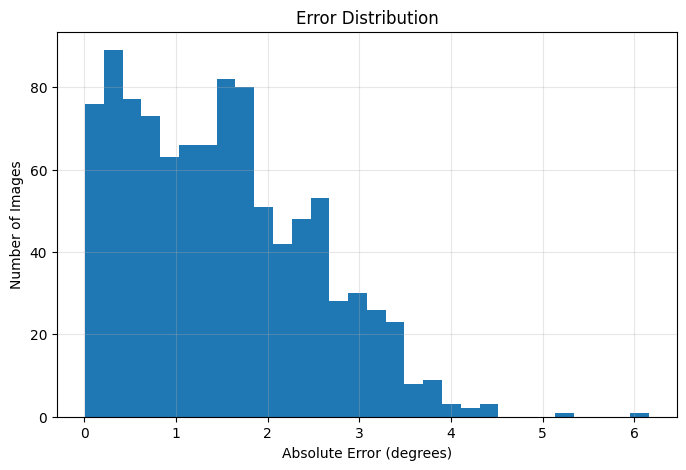

In [33]:
plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.xlabel("Absolute Error (degrees)")
plt.ylabel("Number of Images")
plt.title("Error Distribution")

plt.grid(alpha=0.3)

plt.show()

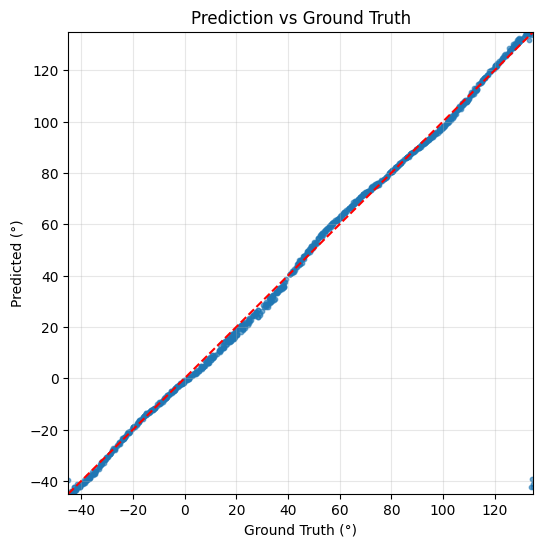

In [34]:
plt.figure(figsize=(6,6))

plt.scatter(true_angles, pred_angles, s=10, alpha=0.6)

plt.plot([-45,135],[-45,135],'r--')

plt.xlim(-45,135)
plt.ylim(-45,135)

plt.xlabel("Ground Truth (°)")
plt.ylabel("Predicted (°)")
plt.title("Prediction vs Ground Truth")

plt.grid(alpha=0.3)

plt.show()

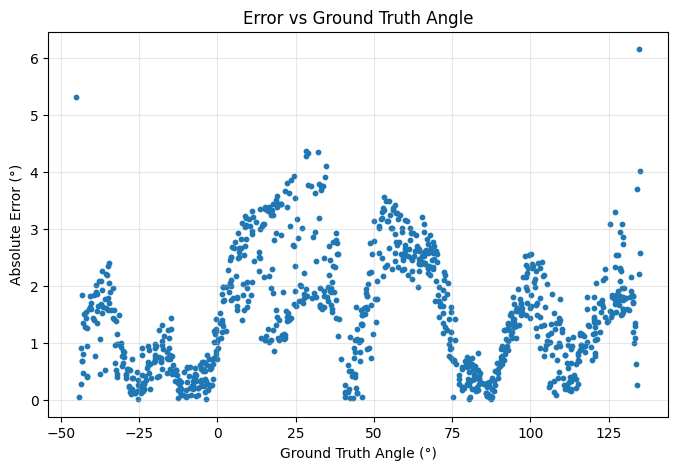

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(true_angles, errors, s=10)

plt.xlabel("Ground Truth Angle (°)")
plt.ylabel("Absolute Error (°)")
plt.title("Error vs Ground Truth Angle")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
results = results.sort_values("AbsoluteError", ascending=False)
    
results.head(20)

,GroundTruth,Prediction,AbsoluteError
403,134.482410,-39.359245,6.158356
868,-44.975755,-39.660873,5.314880
833,28.365158,24.004238,4.360916
82,32.073147,27.725750,4.347397
773,28.983794,24.653250,4.330544
489,28.243433,23.955631,4.287804
481,34.875039,30.765547,4.109489
177,134.949181,-41.027241,4.023575
59,24.612362,20.678389,3.933975
142,34.475490,30.557135,3.918358


GroundTruth      134.482410
Prediction       -39.359245
AbsoluteError      6.158356
Name: 403, dtype: float64


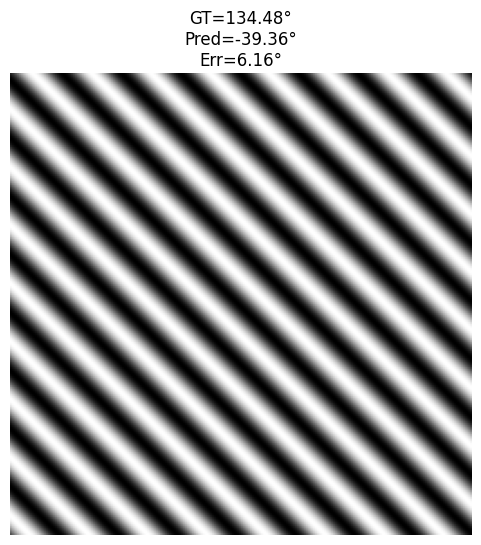

In [37]:
worst = results.sort_values("AbsoluteError", ascending=False).iloc[0]

print(worst)

img = cv2.imread(df.iloc[worst.name]["image"], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title(
    f"GT={worst['GroundTruth']:.2f}°\n"
    f"Pred={worst['Prediction']:.2f}°\n"
    f"Err={worst['AbsoluteError']:.2f}°"
)
plt.axis("off")
plt.show()

In [38]:
img = cv2.imread(df.iloc[185]["image"], cv2.IMREAD_GRAYSCALE)

vec = predict_vector(img)

print(vec)
print("Norm =", np.linalg.norm(vec))
print("Angle =", vector_to_angle(vec))

[0.43479574 0.90052915]
Norm = 1.0
Angle = 25.772295


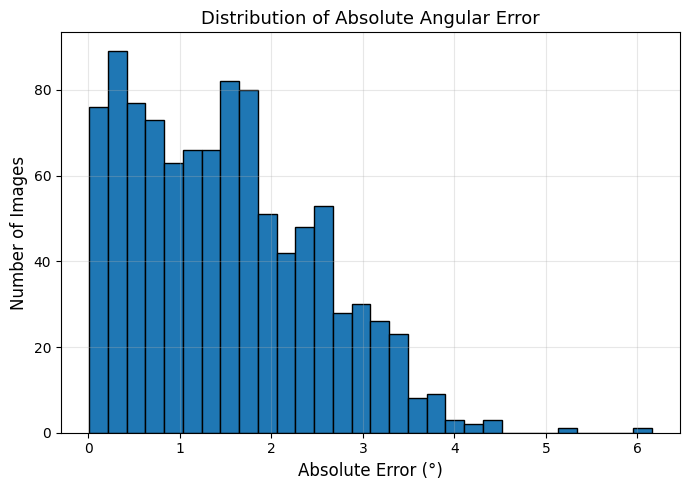

In [39]:
plt.figure(figsize=(7,5))

plt.hist(errors, bins=30, edgecolor='black')

plt.xlabel("Absolute Error (°)", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Absolute Angular Error", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

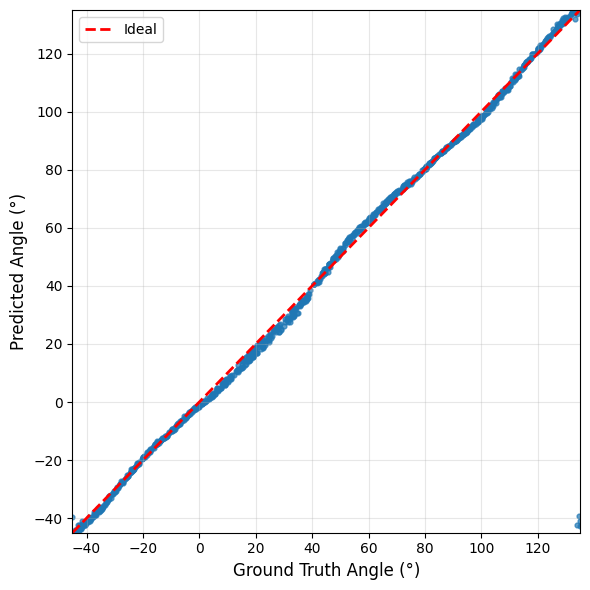

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(
    true_angles,
    pred_angles,
    s=12,
    alpha=0.7
)

plt.plot(
    [-45,135],
    [-45,135],
    'r--',
    linewidth=2,
    label="Ideal"
)

plt.xlim(-45,135)
plt.ylim(-45,135)

plt.xlabel("Ground Truth Angle (°)", fontsize=12)
plt.ylabel("Predicted Angle (°)", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

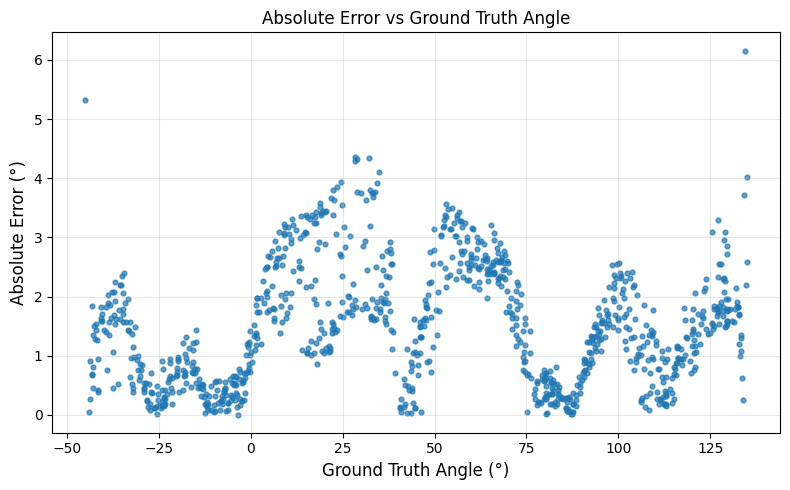

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    true_angles,
    errors,
    s=12,
    alpha=0.7
)

plt.xlabel("Ground Truth Angle (°)", fontsize=12)
plt.ylabel("Absolute Error (°)", fontsize=12)

plt.title("Absolute Error vs Ground Truth Angle")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

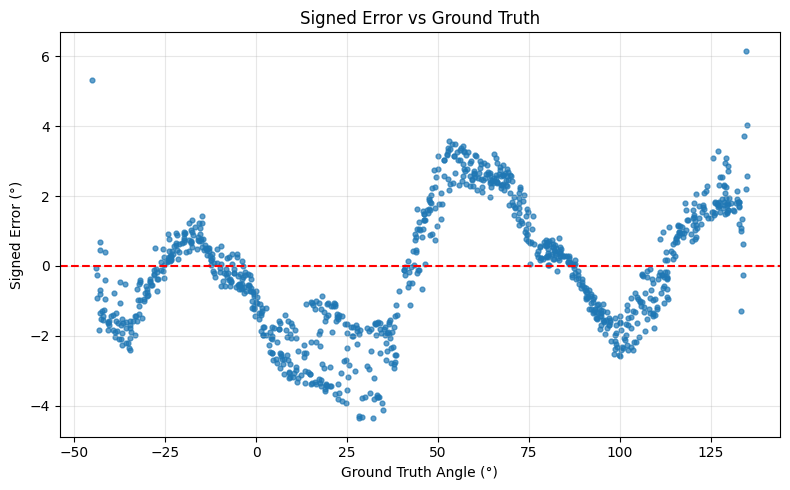

In [42]:
signed_error = ((np.array(pred_angles) - np.array(true_angles) + 90) % 180) - 90

plt.figure(figsize=(8,5))

plt.scatter(
    true_angles,
    signed_error,
    s=12,
    alpha=0.7
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Ground Truth Angle (°)")
plt.ylabel("Signed Error (°)")

plt.title("Signed Error vs Ground Truth")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

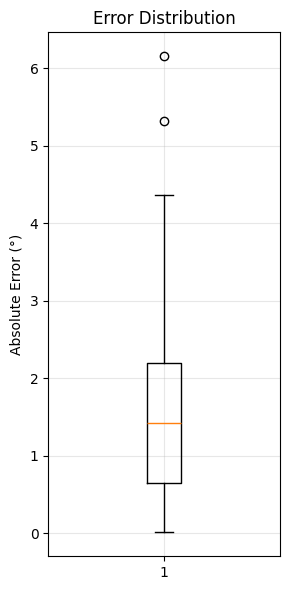

In [43]:
plt.figure(figsize=(3,6))

plt.boxplot(errors)

plt.ylabel("Absolute Error (°)")

plt.title("Error Distribution")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

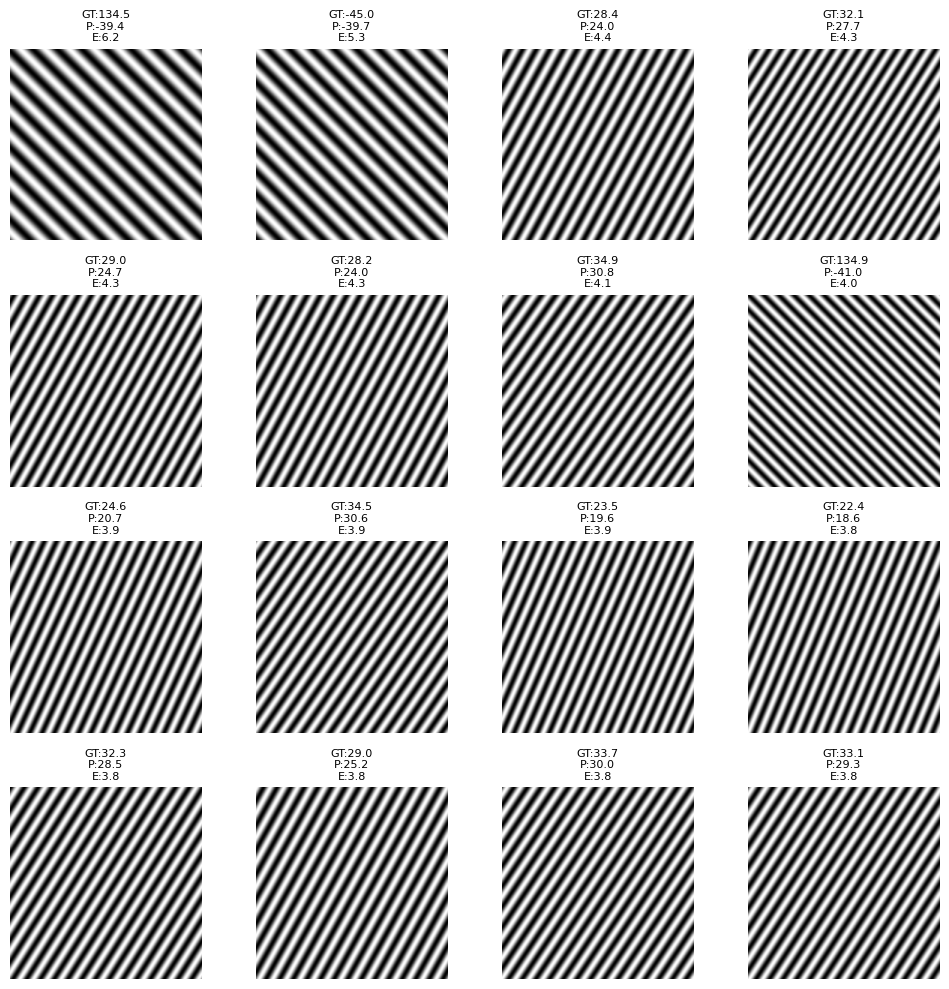

In [44]:
worst = results.sort_values(
    "AbsoluteError",
    ascending=False
).head(16)

fig, axes = plt.subplots(4,4, figsize=(10,10))

for ax, (_, row) in zip(axes.ravel(), worst.iterrows()):

    img = cv2.imread(
        df.loc[row.name, "image"],
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(img, cmap="gray")

    ax.set_title(
        f"GT:{row.GroundTruth:.1f}\n"
        f"P:{row.Prediction:.1f}\n"
        f"E:{row.AbsoluteError:.1f}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

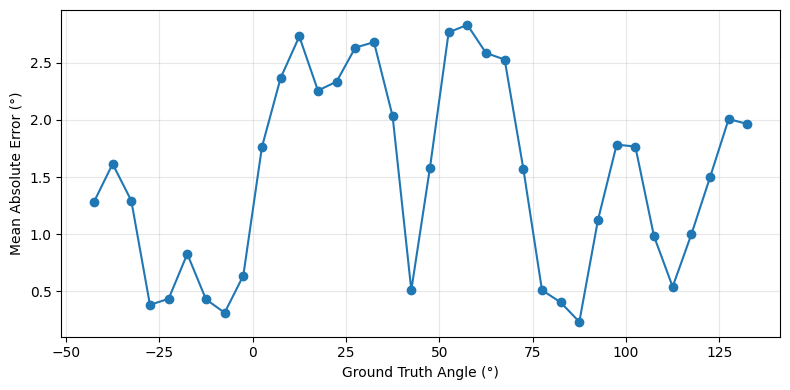

In [45]:
angle_bins = np.arange(-45,136,5)

bin_centers = []
bin_mae = []

for i in range(len(angle_bins)-1):

    mask = (
        (results["GroundTruth"] >= angle_bins[i]) &
        (results["GroundTruth"] < angle_bins[i+1])
    )

    if mask.sum():

        bin_centers.append(
            (angle_bins[i]+angle_bins[i+1])/2
        )

        bin_mae.append(
            results.loc[mask,"AbsoluteError"].mean()
        )

plt.figure(figsize=(8,4))

plt.plot(
    bin_centers,
    bin_mae,
    '-o'
)

plt.xlabel("Ground Truth Angle (°)")
plt.ylabel("Mean Absolute Error (°)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

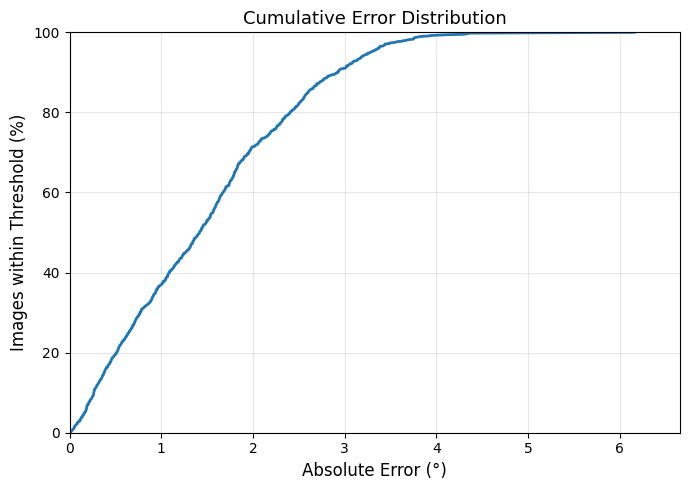

In [46]:
import numpy as np
import matplotlib.pyplot as plt

errors_sorted = np.sort(errors)

cdf = np.arange(1, len(errors_sorted)+1) / len(errors_sorted)

plt.figure(figsize=(7,5))

plt.plot(
    errors_sorted,
    cdf*100,
    linewidth=2
)

plt.xlim(0, max(errors_sorted)+0.5)
plt.ylim(0,100)

plt.xlabel("Absolute Error (°)", fontsize=12)
plt.ylabel("Images within Threshold (%)", fontsize=12)
plt.title("Cumulative Error Distribution", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

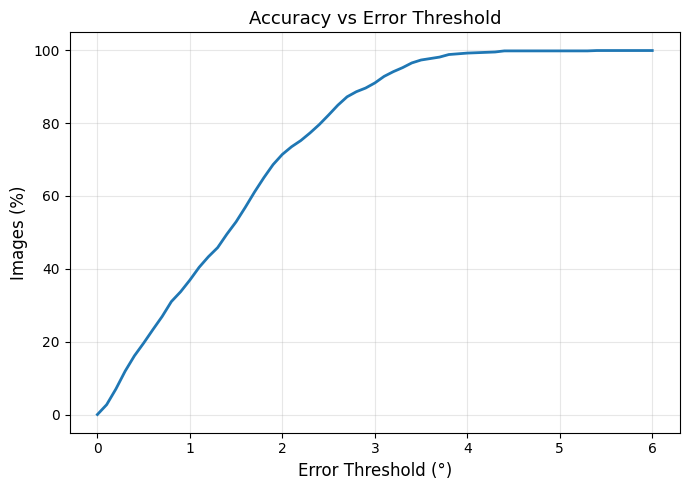

In [47]:
thresholds = np.arange(0, 6.1, 0.1)

accuracy = [
    np.mean(np.array(errors) <= t) * 100
    for t in thresholds
]

plt.figure(figsize=(7,5))

plt.plot(
    thresholds,
    accuracy,
    linewidth=2
)

plt.xlabel("Error Threshold (°)", fontsize=12)
plt.ylabel("Images (%)", fontsize=12)

plt.title("Accuracy vs Error Threshold", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()